In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('credit_risk_dataset.csv')

In [3]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
for column in ['person_emp_length', 'loan_int_rate']:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [7]:
df.duplicated().sum()

np.int64(165)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
from sklearn.preprocessing import OneHotEncoder
df=pd.get_dummies(df,columns=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'])

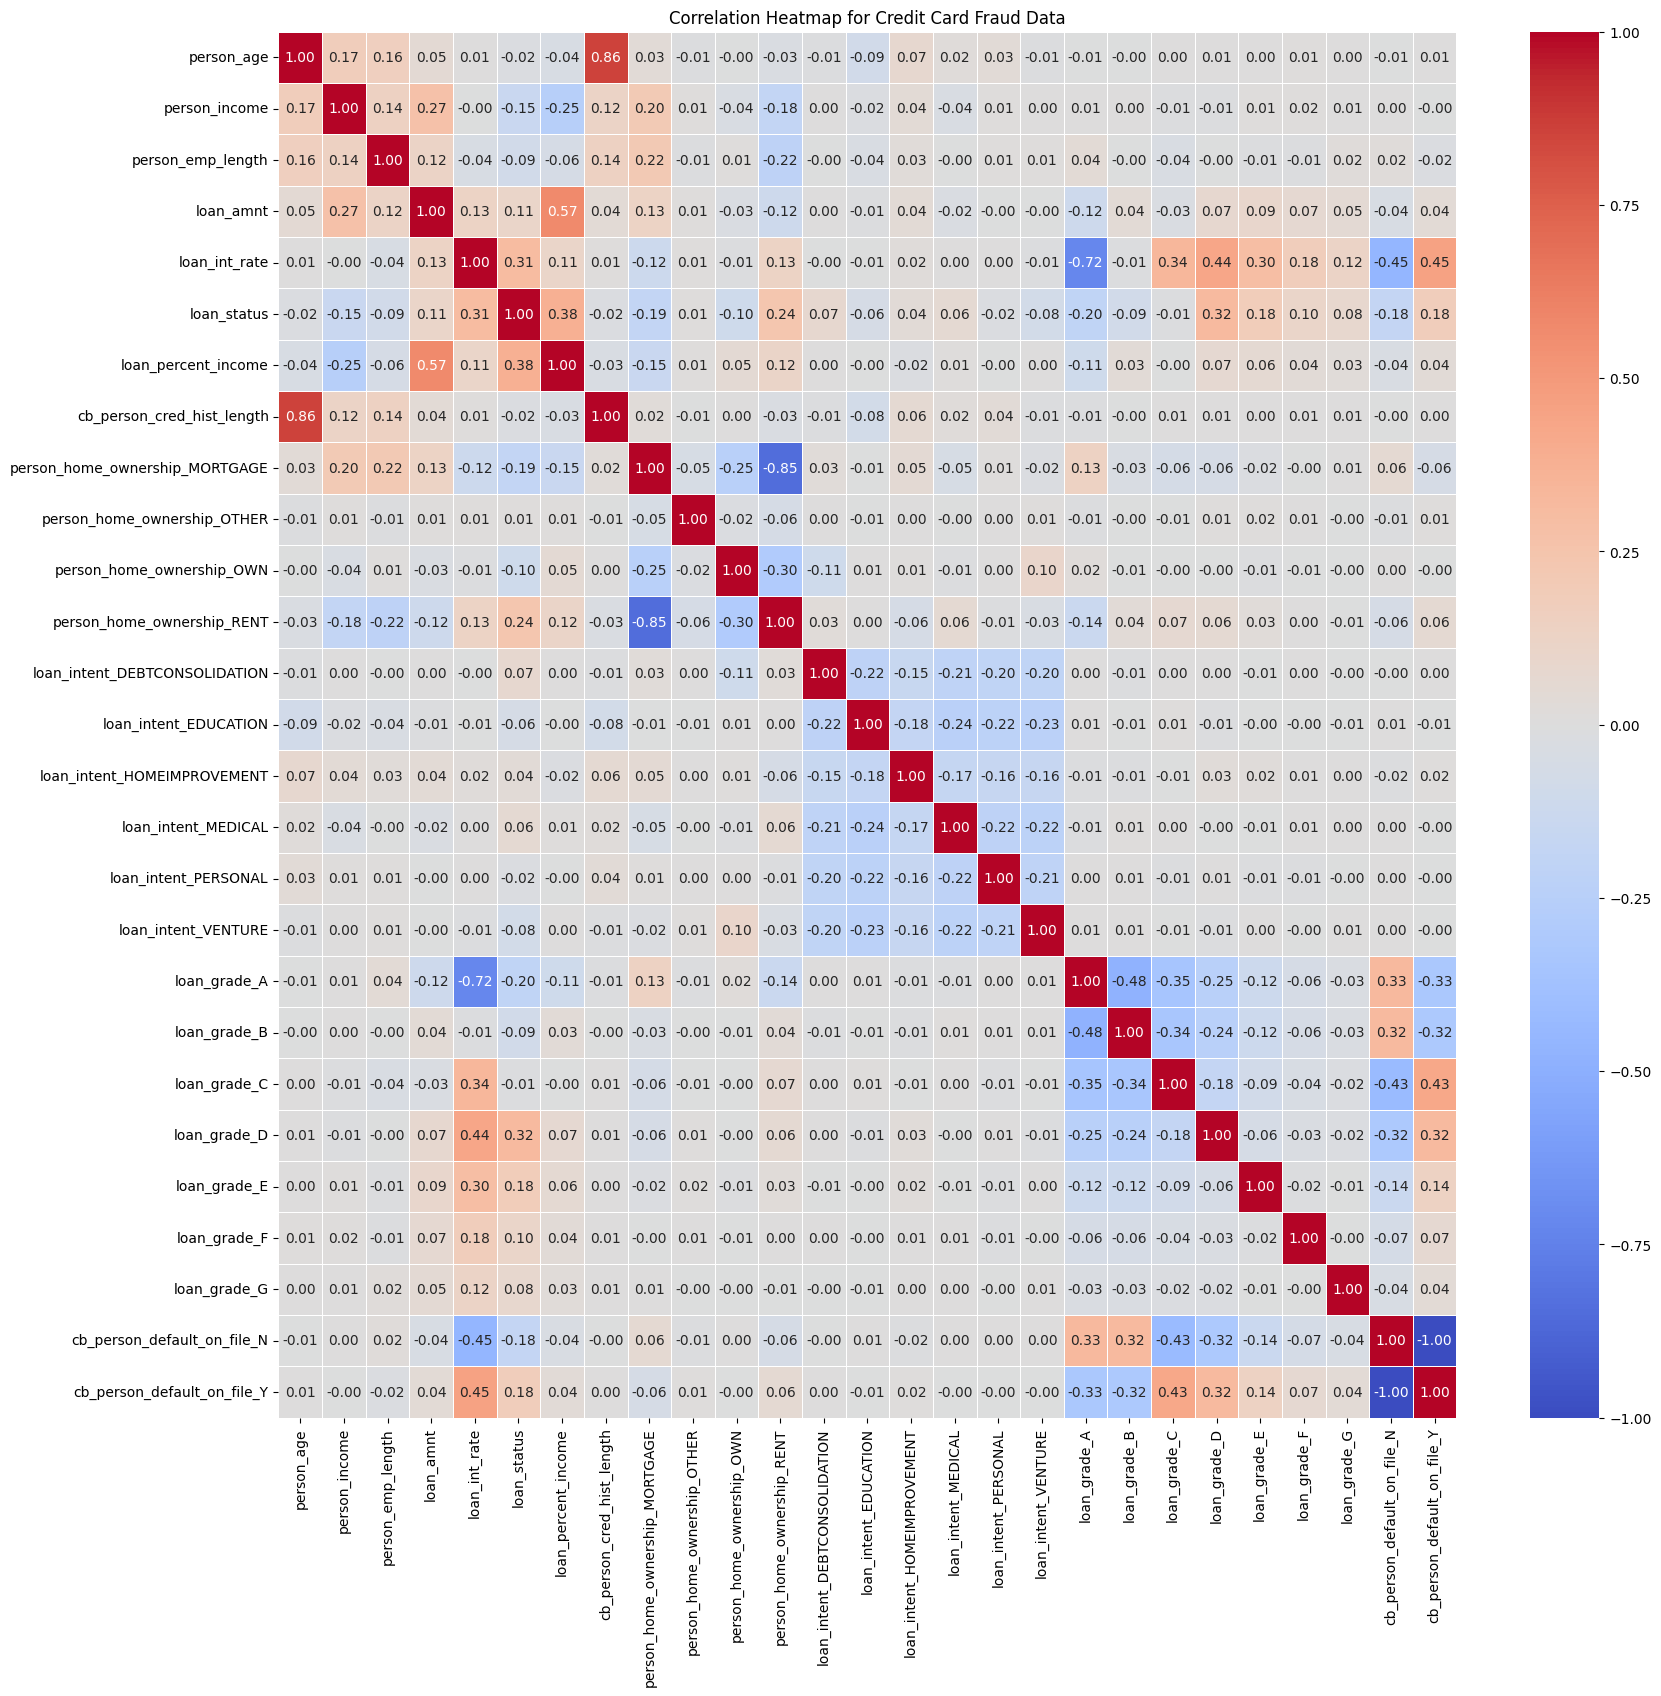

In [10]:
corr_matrix = df.corr()

plt.figure(figsize=(19, 18))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap for Credit Card Fraud Data')
plt.show()

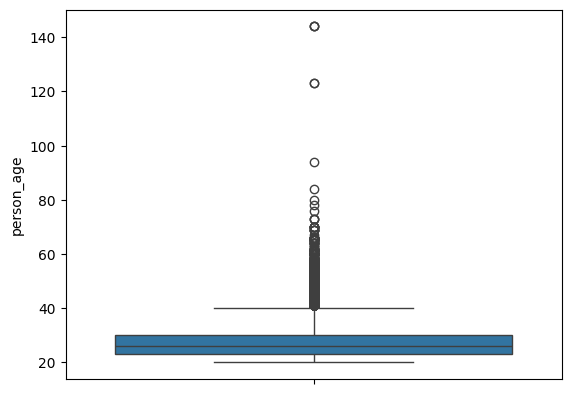

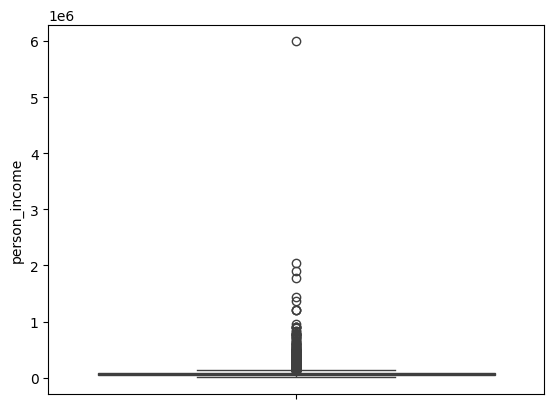

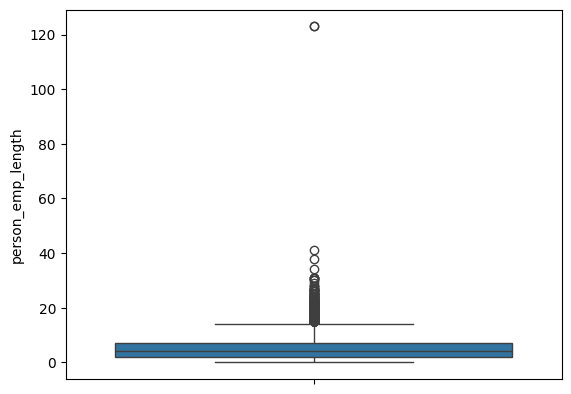

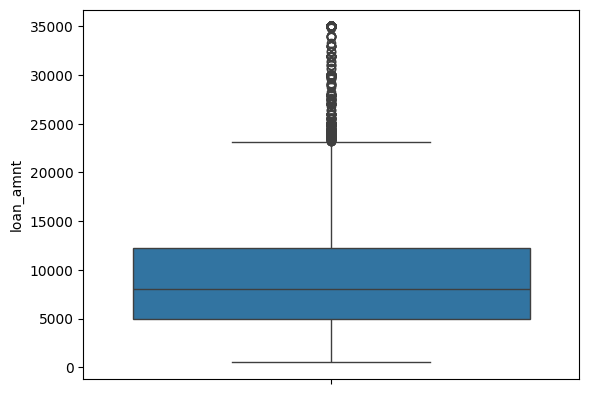

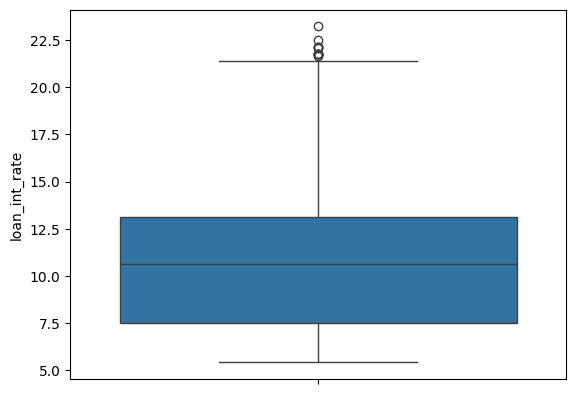

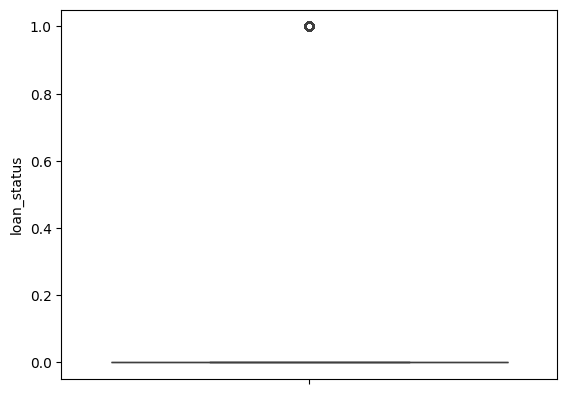

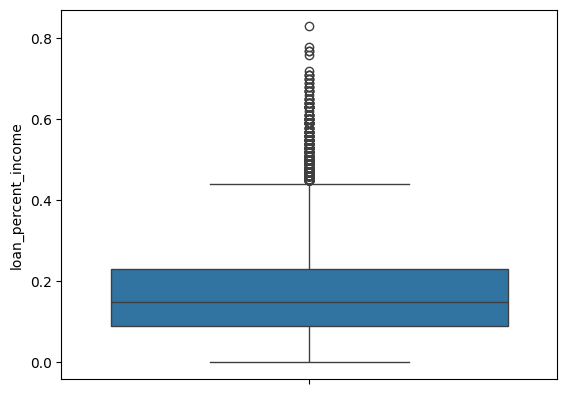

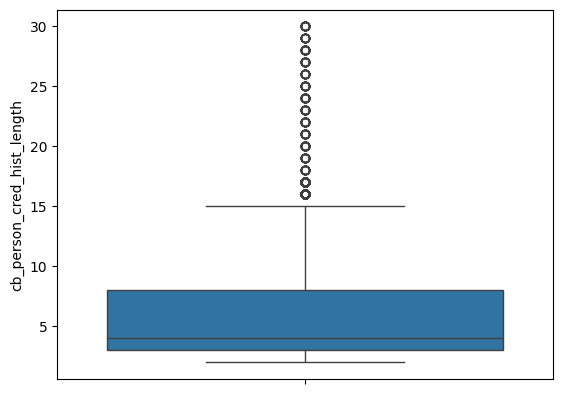

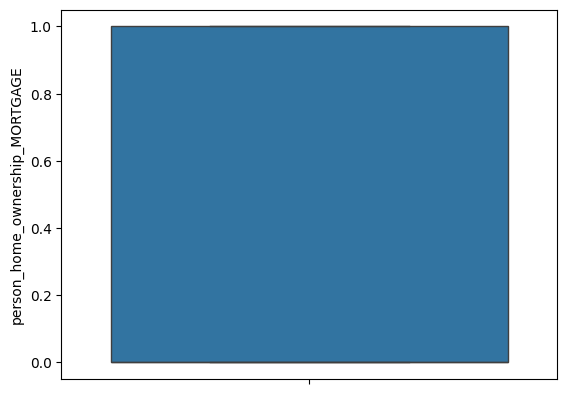

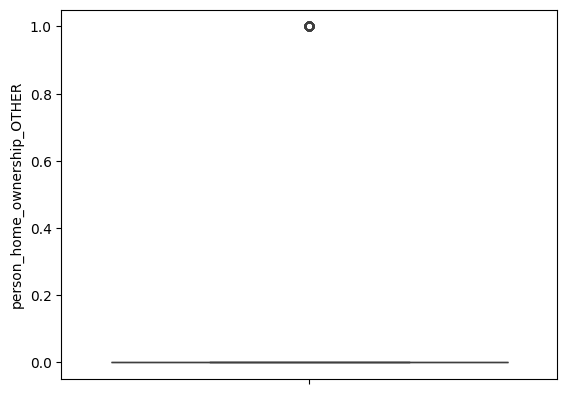

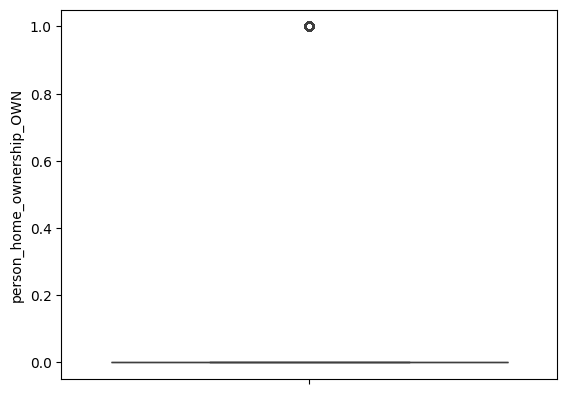

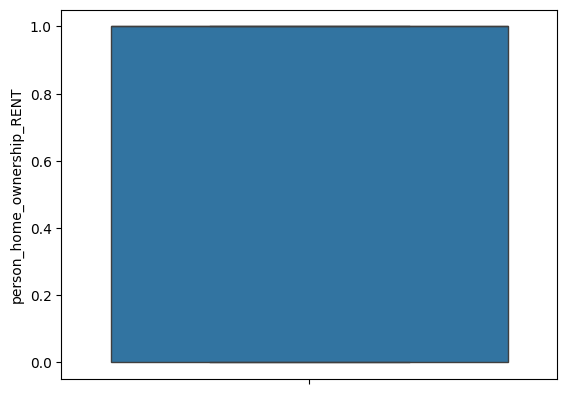

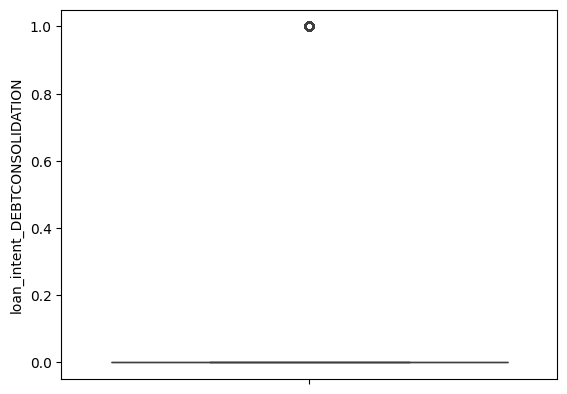

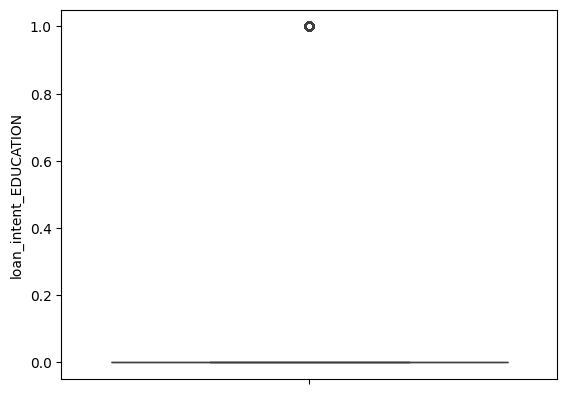

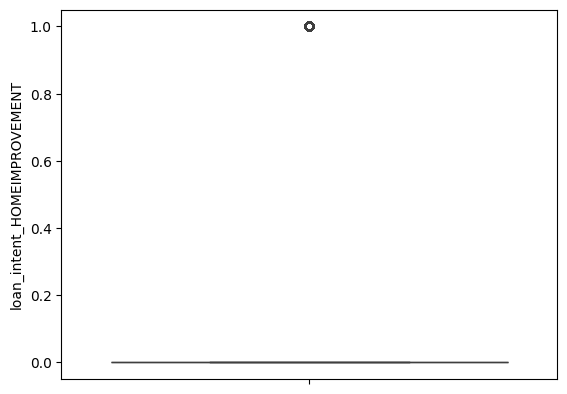

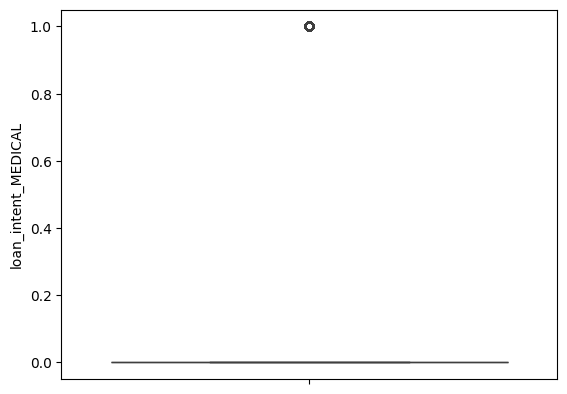

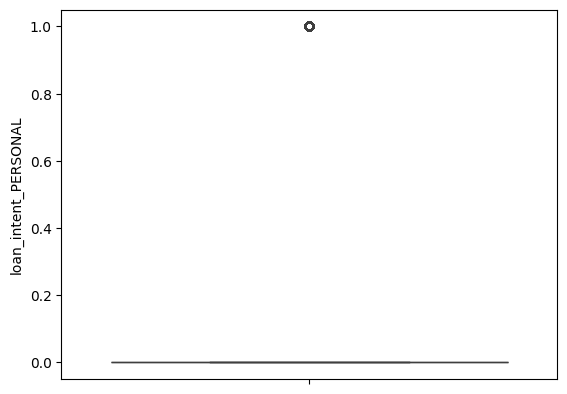

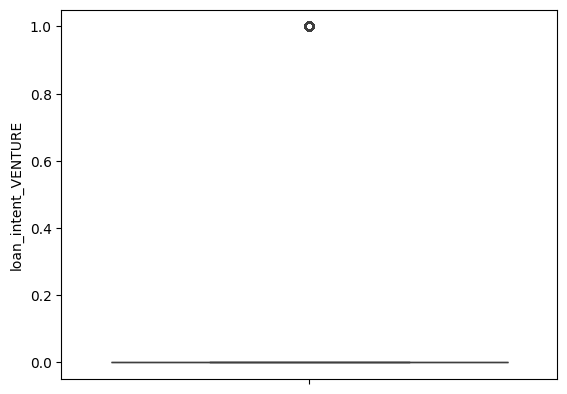

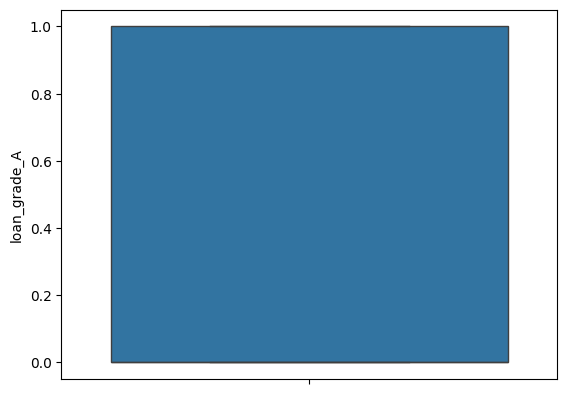

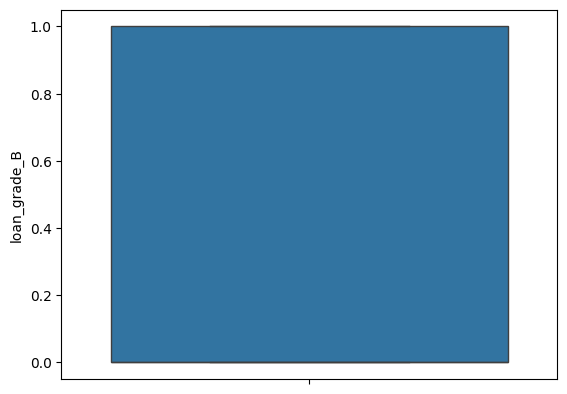

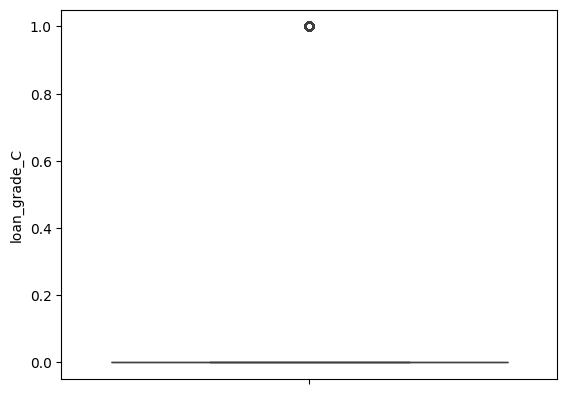

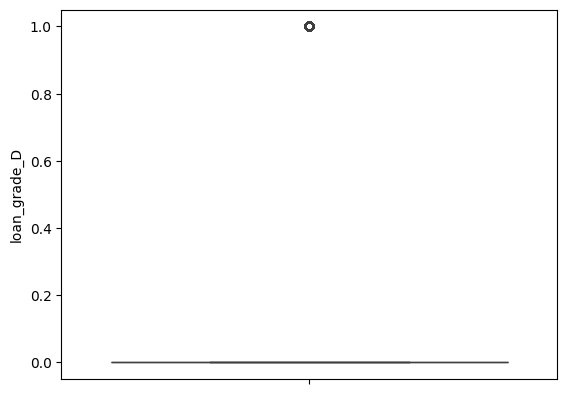

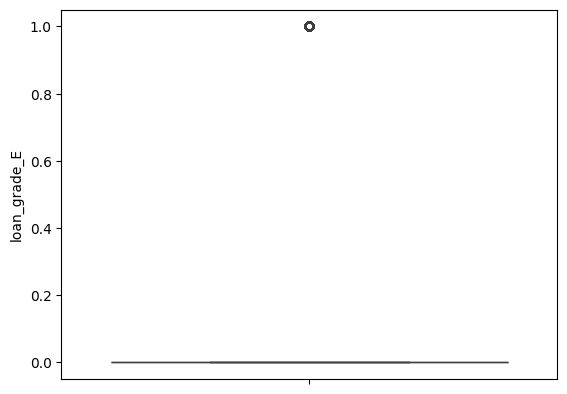

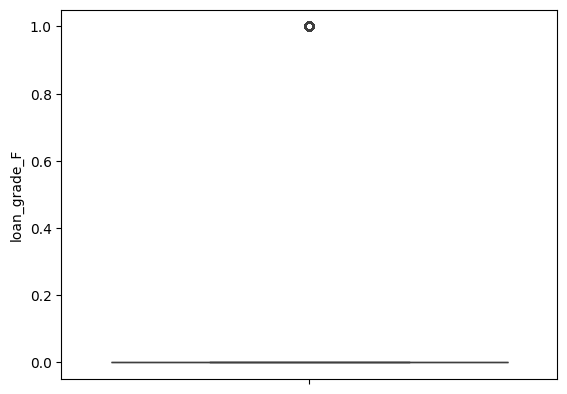

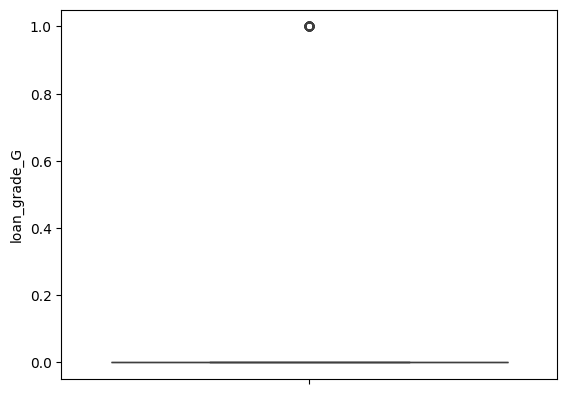

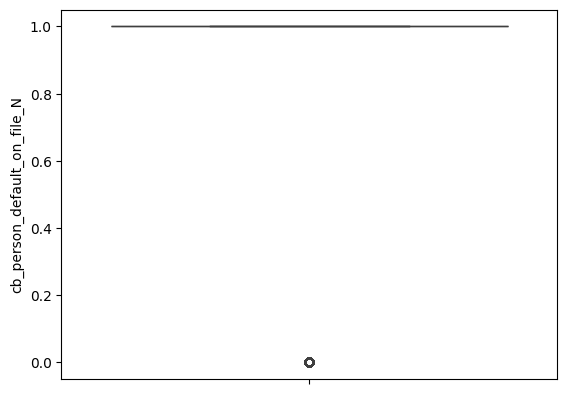

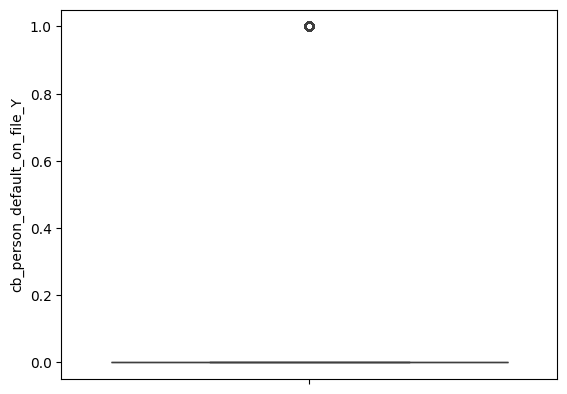

In [11]:
for i in df.columns:
  sns.boxplot(df[i])
  plt.show()

In [12]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [14]:
from sklearn.preprocessing import RobustScaler
rs=RobustScaler()
x_train=rs.fit_transform(x_train)
x_test=rs.transform(x_test)

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# حساب النسبة بين الفئة 0 والفئة 1 (تقريباً 5089/1395 = 3.6)
ratio = 5089 / 1395

# تعريف الموديل مع الوزن الجديد
model = XGBClassifier(
    random_state=42
)

model.fit(x_train, y_train)

# التنبؤ العادي
y_pred = model.predict(x_test)
print("Results with scale_pos_weight:")
print(classification_report(y_test, y_pred))

Results with scale_pos_weight:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5080
           1       0.96      0.72      0.82      1404

    accuracy                           0.93      6484
   macro avg       0.94      0.86      0.89      6484
weighted avg       0.93      0.93      0.93      6484

